In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import roc_auc_score
from tensorflow.keras.layers import Dense, Activation, BatchNormalization, LSTM, Masking, Input, GRU, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from tensorflow.keras import regularizers
from sklearn.utils import shuffle
from qkeras import *
import qkeras
from tensorflow.keras.models import load_model
from qkeras.utils import model_quantize
from qkeras.utils import model_save_quantized_weights

import hls4ml

import os

2025-11-21 12:51:58.476987: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-21 12:51:58.511711: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-21 12:51:58.511752: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-21 12:51:58.512664: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-21 12:51:58.517931: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-21 12:51:58.518813: I tensorflow/core/platform/cpu_feature_guard.cc:1

## GRU

In [8]:
def grumodel(max_len, n_var, rec_units, ndense=[50, 10], l1_reg=0,
              l2_reg=0, rec_act='sigmoid', extra_lab='none', rec_kernel_init='VarianceScaling',
             dense_kernel_init='lecun_uniform'):
    
    hidden = x_in = Input(shape=(max_len, n_var,))
    hidden = GRU(units=rec_units,
                  recurrent_activation = rec_act,
                  kernel_initializer = rec_kernel_init, 
                  name = 'gru')(hidden)
    
    hidden = Dense(50, kernel_initializer=dense_kernel_init, name='dense_0' )(hidden)
    hidden = Activation('relu', name = 'relu_0')(hidden)
    
    hidden = Dense(10, kernel_initializer=dense_kernel_init, name='dense_1' )(hidden)
    hidden = Activation('relu', name = 'relu_1')(hidden)

    hidden = Dense(3, kernel_initializer=dense_kernel_init, name = 'dense_2')(hidden)
    hidden = Activation('softmax', name = 'output_softmax')(hidden)
    
    model = Model(inputs=x_in, outputs=hidden)
    
    return model

## Floating Point Model Training

In [9]:
l1_reg = 0
l2_reg = 0

## GRU Model
model = grumodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)

## LSTM Model
#model = lstmmodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)

model.compile(optimizer='adam', loss=['categorical_crossentropy'], metrics=['accuracy'])
    
model_output = 'gru_test3/gru_weights.h5'

train = False
if train:
    history = model.fit(x_train, y_train,
            batch_size=2**10,
            epochs=150,
            validation_data=(x_val, y_val), 
            shuffle = True,
            sample_weight= w_train,
            callbacks = [
                EarlyStopping(verbose=True, patience=20, monitor='val_accuracy'),
                ModelCheckpoint(model_output, monitor='val_accuracy', verbose=True, save_best_only=True)
                ],
            verbose=True
            )
#y_keras = model.predict(x_test, batch_size=2**10)
#auc_score = roc_auc_score(y_test, y_keras)
#print("AUC score:", auc_score)

In [10]:
# Pruning model
#from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
#from tensorflow_model_optimization.sparsity.keras import strip_pruning

#pruning_params = {"pruning_schedule": pruning_schedule.ConstantSparsity(0.75, begin_step=2000, frequency=100)}
#model = prune.prune_low_magnitude(model, **pruning_params)

## GRU weight

In [11]:
model = load_model("./gru_test3/gru_weights.h5", custom_objects={'QGRU': QGRU, 'QDense': QDense, 'quantized_bits': quantized_bits, 'QActivation': QActivation})

for layer in model.layers:
    weights = layer.get_weights()
    print(layer.name, weights)

input_1 []
gru [array([[-0.12469812, -0.28928995,  0.24783108, ...,  0.09020978,
         1.3361043 ,  0.2131291 ],
       [ 0.1327692 , -0.08152957,  0.25204852, ...,  0.08305766,
        -0.40952712, -0.08306952],
       [-0.03643114,  0.05480863, -0.37831095, ...,  0.08108549,
        -0.20789394,  0.2881709 ],
       [-0.3405804 , -0.132991  , -0.21851636, ..., -0.02375418,
         0.45972824,  0.17867932],
       [-0.5600249 ,  0.20899312, -0.61330974, ...,  0.16689596,
        -0.23248236, -0.6929572 ],
       [-0.2772438 , -0.26483715,  0.39346495, ...,  0.03653004,
        -0.3099163 ,  0.32959458]], dtype=float32), array([[-0.00120384,  0.02518557,  0.11613223, ...,  0.00860514,
        -0.17399853, -0.09032135],
       [ 0.1389099 , -0.01724965,  0.21604231, ...,  0.02770575,
        -0.20152883,  0.09281268],
       [ 0.22167127,  0.25377536, -0.02039688, ..., -0.06135429,
        -0.1431508 ,  0.08396748],
       ...,
       [-0.00848735, -0.08626914, -0.09164452, ...,  0.

## Load QGRU Post Training Weights

In [12]:

#from qkeras.utils import model_quantize

#l1_reg = 0
#l2_reg = 0

### GRU Model
#model = grumodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)

## new_GRU_0int = []
## new_GRU_1int = []
## new_GRU_4int = []
## GRU_1int = []
#for int_bits in [0]:
#    for i in [1]:
#        total_bits = i + int_bits + 1
#        config = {
#            "QGRU":{
#                "kernel_quantizer" : f"quantized_bits({total_bits},{int_bits},1)",
#                 "bias_quantizer" : f"quantized_bits({total_bits}, {int_bits},1)",
#                 "recurrent_quantizer": f"quantized_bits({total_bits},{int_bits},1)",
#                 "state_quantizer" : f"quantized_bits({total_bits},{int_bits},1)"
#            },
#            "QDense":{
#                "kernel_quantizer" : f"quantized_bits({total_bits},{int_bits},1)",
#                "bias_quantizer" : f"quantized_bits({total_bits},{int_bits},1)"
#            },
#            "relu_0" : f"quantized_relu({total_bits},{int_bits},1)",
#            "relu_1" : f"quantized_relu({total_bits},{int_bits},1)",
#        }
#    
#        qmodel = model_quantize(model, config, total_bits, transfer_weights=True)
    
# for layer in qmodel.layers:
#         if hasattr(layer, "recurrent_quantizer"):
#             print(layer.name, "kernel:", str(layer.kernel_quantizer_internal), "bias:", str(layer.bias_quantizer_internal), 
#                     "recurrent:", str(layer.recurrent_quantizer_internal), "state:", str(layer.state_quantizer_internal))
#         elif hasattr(layer, "kernel_quantizer"):
#             print(layer.name, "kernel:", str(layer.kernel_quantizer_internal), "bias:", str(layer.bias_quantizer_internal))
#         elif hasattr(layer, "quantized_relu"):
#             print(layer.name, "quantized_relu:", str(layer.quantizer))
#         else:
#             print(layer.name)
                
#        qmodel.summary()
    
#        qmodel.compile(optimizer='adam', loss=['categorical_crossentropy'], metrics=['accuracy'])
    

In [13]:

#model =  load_model('gru_test3/gru_weights.h5')

#model.load_weights('4int_qgru_test3/2frac_qgru_weights.h5')
#model = load_model('4int_qgru_test3/2frac_qgru_weights.h5', custom_objects={'QGRU': QGRU, 'QDense': QDense, 'quantized_bits': quantized_bits, 'QActivation': QActivation})


#qgru = load_model('4int_qgru_test3/2frac_qgru_weights.h5', custom_objects={'QGRU': QGRU, 'QDense': QDense, 'quantized_bits': quantized_bits, 'QActivation': QActivation})


#model_save_quantized_weights(qgru, f"ptq2int2fra_weight")

### Synthesis of Model

In [ ]:
#import hls4ml

config = hls4ml.utils.config_from_keras_model(model, granularity='name') 
                                # backend='Vivado' #granularity = 'name' #granularity = 'model' 
                                # default_precision='ap_fixed<16,6>' # default_reuse_factor=2
config['Model']['ReuseFactor'] = 16 #24 #16 #4#4096 #1 #28 #0000
config['Model']['IOType'] = 'io_stream'
config['Model']['Strategy'] = 'resource'  #stable
config['Model']['Precision'] = 'ap_fixed<16,6>' #'ap_fixed<4,2>'

config['LayerName']['output_softmax']['implementation'] = 'argmax'

#print("-----------------------------------")
#print("Configuration")
#plotting.print_dict(config) 
#print("-----------------------------------")

#creating hls model using 'Vivado'
backendSynth = 'Vivado' #vitis'
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend=backendSynth, output_dir='models/gru_floating_point/gru_test3_bigBoard_reuse16/hls4ml_prj', 
    #part='xc7vx690tffg1761-2'
    #part='xcu280-fsvh2892-2L-e'
    part='xcvu13p-fhga2104-3-e'
) #vitis #models/vitis/gru_floating_point/gru_test3/hls4ml_prj 
#Vivado # models/gru_floating_point/gru_test3/hls4ml_prj
# #models/qgru_4int/2frac_model_qgru/hls4ml_prj
# models/gru_floating_point/gru_4_2_test3/hls4ml_prj

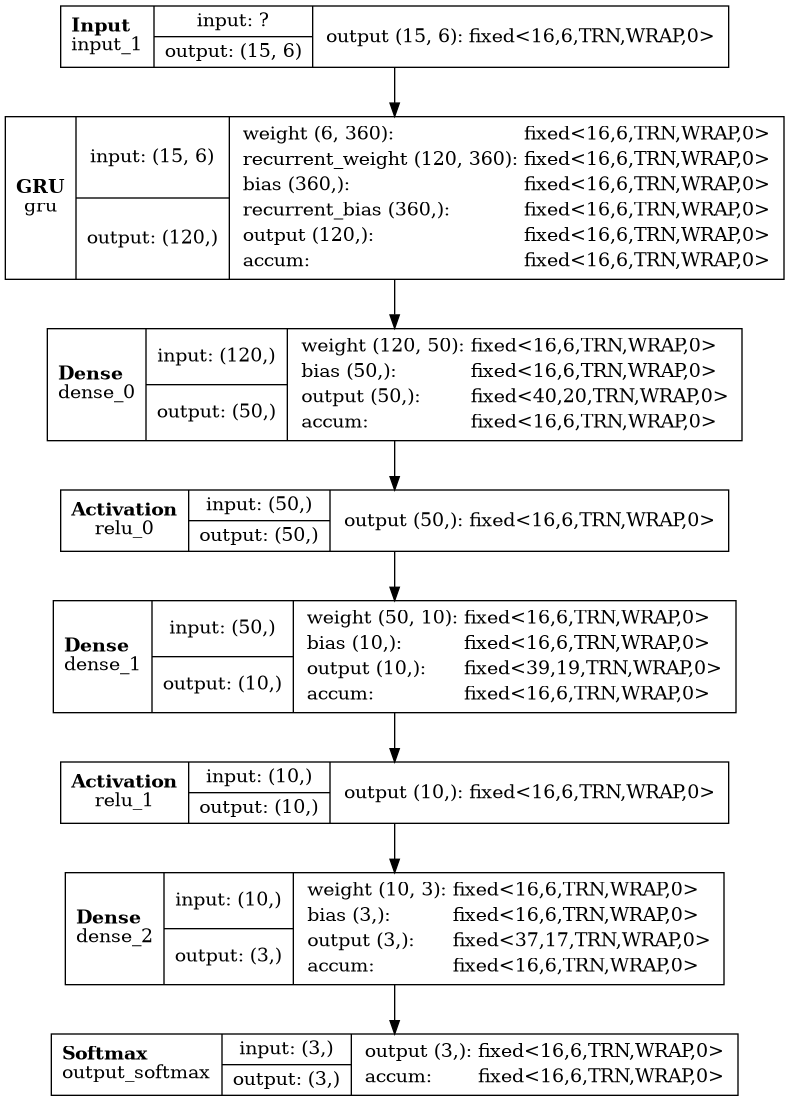

In [15]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

In [16]:
# build the model using HLS
hls_model.build(csim=False) #

# remember to change hls_script to pull from the right file
#os.system(f"vivado -mode batch -source hls_script.tcl")

#os.system(f"vivado -mode batch -source hls_script.tcl -tclargs {name}")

error=f"HLS4ML Script Completed"
os.system(f'printf "Completed building HLS model using {backendSynth}" | mail -s "{error}" ljdono@uw.edu') 


****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2019.1 (64-bit)
  **** SW Build 2552052 on Fri May 24 14:47:09 MDT 2019
  **** IP Build 2548770 on Fri May 24 18:01:18 MDT 2019
    ** Copyright 1986-2019 Xilinx, Inc. All Rights Reserved.

source /tools/Disk_Xilinx/Vivado/2019.1/scripts/vivado_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Disk_Xilinx/Vivado/2019.1/bin/unwrapped/lnx64.o/vivado_hls'
INFO: [HLS 200-10] For user 'quin' on host 'hvm1' (Linux_x86_64 version 5.15.0-161-generic) on Thu Nov 20 12:37:00 PST 2025
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/home/quin/HLS4ML_VS_MANUAL/documents/Benchmarks/Btagging/qkeras/models/gru_floating_point/gru_test3_bigBoard_reuse2/hls4ml_prj'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-10] Opening project '/home/quin/HLS4ML_VS_MANUAL/documents/Benchmarks/Btagging/qkeras/models/gru_floating_point/gru_test3_bigBoard_reuse2/hls4ml_prj/myproject_prj'.
INFO: [HLS 200-10] Add

0

In [ ]:
#hls4ml.report.read_vivado_report('models/gru_floating_point/gru_test3_bigBoard_reuse16/hls4ml_prj/')

Found 1 solution(s) in models/gru_floating_point/gru_test3_bigBoard_reuse16/hls4ml_prj//myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vivado HLS Report for 'myproject'
* Date:           Fri Nov 21 01:24:40 2025

* Version:        2019.1 (Build 2552052 on Fri May 24 15:28:33 MDT 2019)
* Project:        myproject_prj
* Solution:       solution1
* Product family: virtexuplus
* Target device:  xcvu13p-fhga2104-3-e


== Performance Estimates
+ Timing (ns): 
    * Summary: 
    +--------+-------+----------+------------+
    |  Clock | Target| Estimated| Uncertainty|
    +--------+-------+----------+------------+
    |ap_clk  |   5.00|     4.302|        0.62|
    +--------+-------+----------+------------+

+ Latency (clock cycles): 
    * Summary: 
    +-----+-----+-----+-----+----------+
    |  Latency  |  Interval | Pipeline |
    | min | max | min | max |   Type   |
    +-----+-----+-----+-----+----------+
    |  468|  486|  422|  437